# S&P 500 Portfolio Performance & Risk Analysis

## Project Overview
This notebook builds an end-to-end data pipeline that:
- Scrapes Wikipedia for current S&P 500 constituents
- Stores company metadata and historical prices in a SQLite star schema
- Calculates daily adjusted returns
- Constructs a point-in-time Top 10 portfolio (ranked on 2016–2020 performance)
- Measures out-of-sample performance and risk metrics from 2021 onwards
- Compares the portfolio against the SPY benchmark

The goal is to demonstrate data engineering, transformation, analysis and visualisation skills while applying basic math-based finance concepts.

In [5]:
# Step 0. Project setup - Installing & importing required libraries
!pip install yfinance pandas numpy sqlalchemy matplotlib seaborn

# 0.1. Required library imports
import numpy as np
import pandas as pd
import sqlite3
import datetime
import logging
import requests
import yfinance as yf
from io import StringIO
from bs4 import BeautifulSoup
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import seaborn as sns

# 0.2. Setting up logging logic
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("Initializing Data Engineering Pipeline...")

In [6]:
# Step 1. Setting up the database schema & architecture

# 1.1. Create database engine
db_engine = create_engine('sqlite:///sp500_db_engine.db')

# -------------------------------------------------------------------
# 1.2. Define SQL Schema Architecture (DDL)
# -------------------------------------------------------------------
ddl_schema = """
-- Dimension Table: Asset Metadata
CREATE TABLE IF NOT EXISTS dim_assets (
    ticker TEXT PRIMARY KEY,
    company_name TEXT,
    sector TEXT,
    industry TEXT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

-- Fact Table: Historical Daily Prices (OHLCV)
CREATE TABLE IF NOT EXISTS fact_daily_prices (
    ticker TEXT NOT NULL,
    price_date TEXT NOT NULL,
    open_price REAL,
    high_price REAL,
    low_price REAL,
    close_price REAL,
    adj_close_price REAL,
    volume INTEGER,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (ticker, price_date),
    FOREIGN KEY (ticker) REFERENCES dim_assets(ticker)
);

-- Fact Table: Calculated Daily Returns
CREATE TABLE IF NOT EXISTS fact_daily_returns (
    ticker TEXT NOT NULL,
    price_date TEXT NOT NULL,
    daily_return REAL,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (ticker, price_date),
    FOREIGN KEY (ticker) REFERENCES dim_assets(ticker)
);
"""

# Execute Schema Creation
with db_engine.begin() as conn:
    for statement in ddl_schema.split(';'):
        if statement.strip():
            conn.execute(text(statement))

logging.info("Database Schema explicitly created.")

In [7]:
## Step 2. API Extraction & Metadata Database Ingestion

# -------------------------------------------------------------------
# 2.1. Extraction & Transformation Function
# -------------------------------------------------------------------
def extract_sp500_from_wikipedia() -> pd.DataFrame:

## Extracts and cleans S&P 500 constituent metadata directly from Wikipedia.
## Formats column names to align with the SQL DDL schema for dim_assets.

    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

    try:
        logging.info("Initiating HTTP GET request to Wikipedia for S&P 500 list...")
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")
        table = soup.find("table", {"id": "constituents"})

        # StringIO prevents the Pandas read_html FutureWarning (as read_html will be deprecated)
        df_list = pd.read_html(StringIO(str(table)))
        df_raw = df_list[0]

        logging.info(f"Successfully scraped {len(df_raw)} raw rows from Wikipedia.")

        # Map Wikipedia columns to dim_assets SQL schema
        df_cleaned = df_raw.rename(columns={
            'Symbol': 'ticker',
            'Security': 'company_name',
            'GICS Sector': 'sector',
            'GICS Sub-Industry': 'industry'
        })[['ticker', 'company_name', 'sector', 'industry']]

        # Standardize tickers (e.g. BRK.B -> BRK-B) for yfinance compatibility in Step 4
        df_cleaned['ticker'] = df_cleaned['ticker'].str.replace('.', '-', regex=False)

        # -------------------------------------------------------------------
        # Benchmark: Append SPY (instead of ^GSPC)
        # SPY is used as the benchmark because it includes total dividend returns, matching the total-return treatment applied to individual stocks.
        # -------------------------------------------------------------------
        benchmark_entry = pd.DataFrame([{
            'ticker': 'SPY',
            'company_name': 'SPDR S&P 500 ETF Trust',
            'sector': 'Index Benchmark',
            'industry': 'Index Benchmark'
        }])

        df_final = pd.concat([df_cleaned, benchmark_entry], ignore_index=True)
        return df_final

    except Exception as e:
        logging.error(f"Error extracting data from Wikipedia: {e}")
        raise

# -------------------------------------------------------------------
# 2.2. Database Load Function
# -------------------------------------------------------------------
def load_dim_assets(engine, df_assets: pd.DataFrame):

## Loads cleaned asset metadata into the SQLite database table 'dim_assets'.
## Clears existing records first to avoid Primary Key / UNIQUE constraint errors.

    try:
        logging.info("Clearing existing records in 'dim_assets' to allow safe re-runs...")
        ## Clears existing dim_assets to not run into an existing index entry error
        with engine.begin() as conn:
            conn.execute(text("DELETE FROM dim_assets;"))

        logging.info("Writing extracted constituents into SQLite table 'dim_assets'...")
        df_assets.to_sql(
            name='dim_assets',
            con=engine,
            if_exists='append',
            index=False,
            chunksize=100
        )
        logging.info(f"Successfully loaded {len(df_assets)} records into 'dim_assets'.")

    except Exception as e:
        logging.error(f"Failed to load data into database: {e}")
        raise

# ===================================================================
# 2.3. Execution Block: (API/Web Extraction & Database Load)
# ===================================================================

# Extract and Transform data from Wikipedia
df_sp500_constituents = extract_sp500_from_wikipedia()

# Load the cleaned DataFrame into SQLite using the db_engine from Step 2
load_dim_assets(db_engine, df_sp500_constituents)

# Data Engineering Validation Check (Query SQLite directly)
with db_engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM dim_assets;")).scalar()
    print(f"\n Data Validation: Found {result} total records stored in 'dim_assets' table.")


 Data Validation: Found 504 total records stored in 'dim_assets' table.


In [8]:
## Step 3. Fetching & Storing Historical Market Data

# ===================================================================
# 3.1. Price Extraction Function via yfinance
# ===================================================================

# Reads active tickers from dim_assets and fetches historical daily stock prices using yfinance in a single bulk API call.
def fetch_historical_prices(engine, start_date: str = "2016-01-01", end_date: str = None) -> pd.DataFrame:

    # Retrieve all valid tickers from dim_assets
    with engine.connect() as conn:
        tickers_df = pd.read_sql("SELECT ticker FROM dim_assets;", conn)
        tickers = tickers_df['ticker'].tolist()

    logging.info(f"Retrieved {len(tickers)} tickers from 'dim_assets'. Requesting historical prices from {start_date}...")

    # Download bulk price data from yfinance
    raw_data = yf.download(
        tickers=tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,  # Retain both Close and Adj Close
        threads=True        # Enables multi-threading for speed
    )

    logging.info("Transforming yfinance output into relational database format...")

    # Reshape the MultiIndex DataFrame (Columns -> Rows)
    # Stack level 1 (Ticker) into index to create flat table structure
    if isinstance(raw_data.columns, pd.MultiIndex):
        df_stacked = raw_data.stack(level=1, future_stack=True).reset_index()
    else:
        df_stacked = raw_data.reset_index()
        df_stacked['Ticker'] = tickers[0]

    # Standardize column names (handles casing variations like 'Ticker' vs 'ticker', 'Date' vs 'date')
    df_stacked.columns = [str(c).lower().replace(' ', '_') for c in df_stacked.columns]

    # Schema mapping to match fact_daily_prices DDL
    column_mapping = {
        'date': 'price_date',
        'open': 'open_price',
        'high': 'high_price',
        'low': 'low_price',
        'close': 'close_price',
        'adj_close': 'adj_close_price',
        'adj close': 'adj_close_price',
        'volume': 'volume'
    }

    df_cleaned = df_stacked.rename(columns=column_mapping)

    # Ensure all required columns exist in schema
      # This protects the program in case the
    required_cols = ['ticker', 'price_date', 'open_price', 'high_price', 'low_price', 'close_price', 'adj_close_price', 'volume']
    df_cleaned = df_cleaned[[col for col in required_cols if col in df_cleaned.columns]]

    # Standardize date format to YYYY-MM-DD for SQLite storage
    df_cleaned['price_date'] = pd.to_datetime(df_cleaned['price_date']).dt.strftime('%Y-%m-%d')

    # Clean null rows
    df_cleaned = df_cleaned.dropna(subset=['close_price'])

    return df_cleaned


# ===================================================================
# 3.2. Database Loader Function for Fact Table
# ===================================================================
def load_fact_daily_prices(engine, df_prices: pd.DataFrame):

## Clears existing records and loads transformed price records into 'fact_daily_prices'.

    try:
        logging.info("Clearing existing records in 'fact_daily_prices' to allow safe re-runs...")
        with engine.begin() as conn:
            conn.execute(text("DELETE FROM fact_daily_prices;"))

        logging.info(f"Ingesting {len(df_prices):,} historical price rows into 'fact_daily_prices'...")

        # Batch insert for fast pipeline loading
        df_prices.to_sql(
            name='fact_daily_prices',
            con=engine,
            if_exists='append',
            index=False,
            chunksize=10000
        )
        logging.info("Successfully loaded historical price data into 'fact_daily_prices'.")

    except Exception as e:
        logging.error(f"Failed to load price data into database: {e}")
        raise


# ===================================================================
# 3.3. Execution Block
# ===================================================================
# Step A: Download historical prices starting from 2016
df_prices_cleaned = fetch_historical_prices(db_engine, start_date="2016-01-01")

# Step B: Load cleaned prices into database
load_fact_daily_prices(db_engine, df_prices_cleaned)

# Step C: Data Validation Query
with db_engine.connect() as conn:
    total_rows = conn.execute(text("SELECT COUNT(*) FROM fact_daily_prices;")).scalar()
    unique_tickers = conn.execute(text("SELECT COUNT(DISTINCT ticker) FROM fact_daily_prices;")).scalar()

    print(f"Data Validation Complete:")
    print(f" - Total price records stored: {total_rows:,}")
    print(f" - Unique tickers populated:   {unique_tickers}")

[*********************100%***********************]  504 of 504 completed


Data Validation Complete:
 - Total price records stored: 1,297,167
 - Unique tickers populated:   504


In [9]:
# Step 4. Calculate Daily Percentage Returns & Insert into fact_daily_returns
# ===================================================================
# 4.1. Calculate Daily Returns Function
# ===================================================================
def compute_and_load_daily_returns(engine):

## Retrieves adjusted close prices from fact_daily_prices, calculates daily percentage returns grouped by ticker, and loads results into fact_daily_returns.

    logging.info("Querying fact_daily_prices for return calculations...")

    # Query price history sorted by ticker and date
    query = """
    SELECT ticker, price_date, adj_close_price
    FROM fact_daily_prices
    ORDER BY ticker, price_date ASC;
    """

    with engine.connect() as conn:
        df_prices = pd.read_sql(query, conn)

    logging.info(f"Loaded {len(df_prices):,} price records. Computing pct_change per ticker...")

    # Calculate percentage change within each ticker group using Adjusted Close
    df_prices['daily_return'] = df_prices.groupby('ticker')['adj_close_price'].pct_change()

    # Drop initial NaN rows per ticker (the first date per ticker has no prior date to calculate return)
    df_returns = df_prices.dropna(subset=['daily_return'])[['ticker', 'price_date', 'daily_return']].copy()

    # Load into database
    try:
        logging.info("Clearing existing records in 'fact_daily_returns'...")
        with engine.begin() as conn:
            conn.execute(text("DELETE FROM fact_daily_returns;"))

        logging.info(f"Ingesting {len(df_returns):,} return rows into 'fact_daily_returns'...")
        df_returns.to_sql(
            name='fact_daily_returns',
            con=engine,
            if_exists='append',
            index=False,
            chunksize=10000
        )
        logging.info("Successfully populated 'fact_daily_returns'.")

    except Exception as e:
        logging.error(f"Failed to populate daily returns: {e}")
        raise

# ===================================================================
# 4.2. Execution & Validation
# ===================================================================
compute_and_load_daily_returns(db_engine)

# Data Validation Query
with db_engine.connect() as conn:
    total_returns = conn.execute(text("SELECT COUNT(*) FROM fact_daily_returns;")).scalar()

    # Quick sample query checking returns for Apple (AAPL)
    sample_df = pd.read_sql("""
        SELECT ticker, price_date, round(daily_return * 100, 2) AS return_pct
        FROM fact_daily_returns
        WHERE ticker = 'AAPL'
        ORDER BY price_date DESC
        LIMIT 5;
    """, conn)

    print(f"Daily Returns Calculation Complete:")
    print(f" - Total calculated return rows stored: {total_returns:,}\n")
    print("Latest 5 Daily Returns for AAPL:")
    print(sample_df.to_string(index=False))

Daily Returns Calculation Complete:
 - Total calculated return rows stored: 1,296,663

Latest 5 Daily Returns for AAPL:
ticker price_date  return_pct
  AAPL 2026-07-29       -0.56
  AAPL 2026-07-28        0.94
  AAPL 2026-07-27        1.17
  AAPL 2026-07-24        3.53
  AAPL 2026-07-23       -1.30


## Methodology Notes & Limitations

### Point-in-Time Ranking
Stocks are ranked by total return over the **2016–2020** period only.  
The Top 10 selected stocks are then evaluated on the **2021–present** out-of-sample period.  
This approach removes look-ahead bias from the stock selection process.

### Why SPY is used as the benchmark instead of ^GSPC
Initially, I planned to use the ^GSPC index since it's the standard ticker for tracking S&P 500 performance. However, during testing, I realized it only tracks price movement and ignores dividends, unlike SPY, which provides a more fair comparrison against dividend-paying stocks or funds.

Because the individual stock returns in this analysis are calculated from adjusted close prices (which also include dividends and splits), using SPY provides a like-for-like comparison.  
Using the pure price index ^GSPC would understate the benchmark’s true performance and make the portfolio appear better than it really is relative to the market.

### Important Limitations
1. **Survivorship Bias**  
   The analysis uses the current S&P 500 membership list. Companies that were removed from the index between 2016 and 2026 are excluded, which tends to inflate historical performance.

2. **Look-ahead Bias (partially mitigated)**  
   While the ranking itself is point-in-time, the universe of stocks is still today’s constituents rather than the actual S&P 500 membership that existed in 2016–2020.

3. **Portfolio Construction**  
   The portfolio uses equal weighting with dynamic rebalancing across available stocks on each day (NaNs are skipped). This is not a pure buy-and-hold strategy.

These limitations mean the results should be interpreted as an exploratory analysis rather than a realistic investable backtest.

TOP 10 STOCKS RANKED ON 2016–2020 PERFORMANCE (point-in-time)
ticker           company_name                 sector  total_return_pct_2016_2020
   AMD Advanced Micro Devices Information Technology                     3210.83
   XYZ            Block, Inc.             Financials                     1689.80
  NVDA                 Nvidia Information Technology                     1548.76
  TSLA            Tesla, Inc. Consumer Discretionary                     1479.32
  VEEV          Veeva Systems            Health Care                      848.94
  ALGN       Align Technology            Health Care                      731.46
  GNRC                Generac            Industrials                      686.61
  AXON        Axon Enterprise            Industrials                      628.05
  IDXX     Idexx Laboratories            Health Care                      602.85
  PODD    Insulet Corporation            Health Care                      589.77

Selected tickers: ['AMD', 'XYZ', 'NVDA', 'TSLA

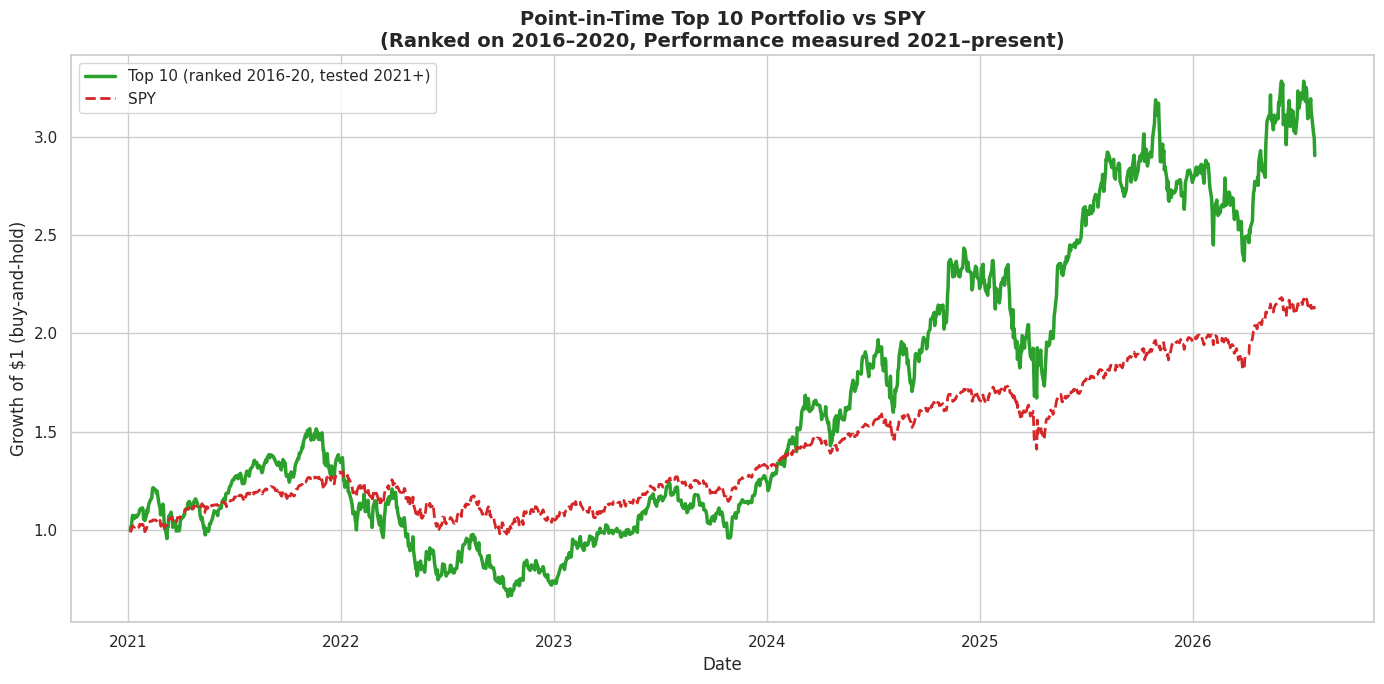

RISK & PERFORMANCE METRICS (Test Period: 2021 onwards)
                  Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  \
Top 10 Portfolio            18.08                32.67          0.49   
SPY                         14.80                16.80          0.76   

                  Sortino Ratio  Max Drawdown (%)  
Top 10 Portfolio           0.74            -55.71  
SPY                        1.05            -24.50  



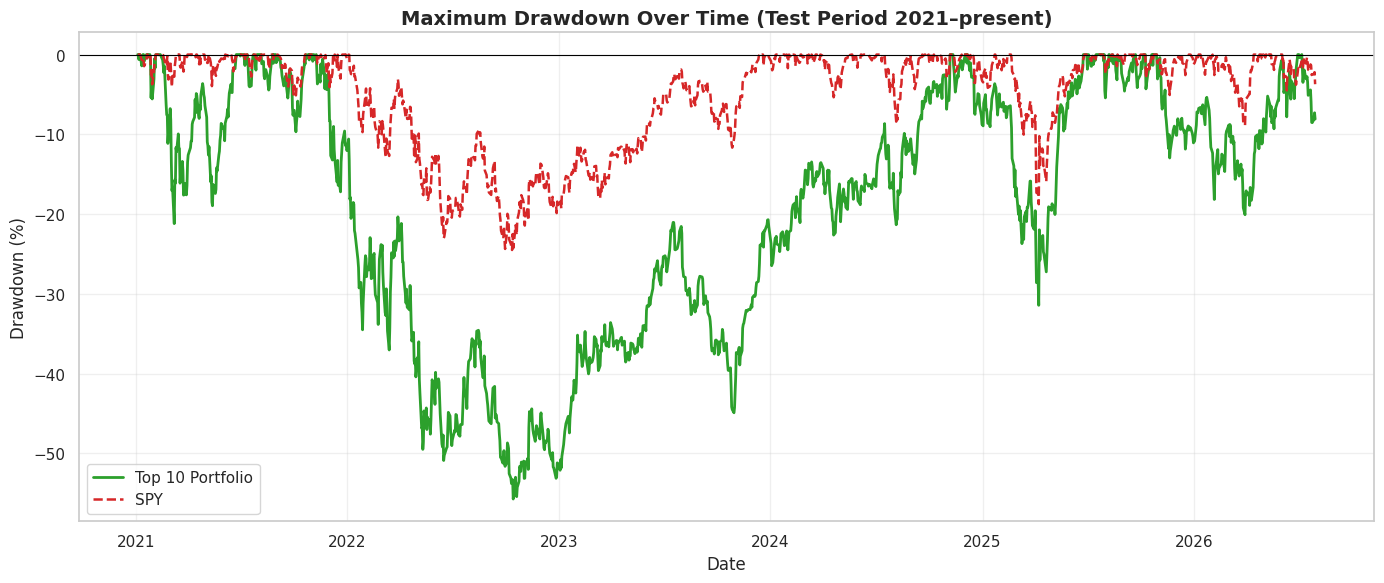

In [10]:
# ============================================================
# Step 5. Point-in-time Top 10 (rank 2016-2020, test 2021+)
# ============================================================

RANK_START = '2016-01-01'
RANK_END   = '2020-12-31'
TEST_START = '2021-01-01'

# ----------------------------------------------------------
# 5.1 Rank stocks on the 2016-2020 window only
# ----------------------------------------------------------
rank_query = f"""
WITH price_bounds AS (
    SELECT
        p.ticker,
        FIRST_VALUE(p.adj_close_price) OVER (
            PARTITION BY p.ticker ORDER BY p.price_date ASC
        ) AS start_price,
        LAST_VALUE(p.adj_close_price) OVER (
            PARTITION BY p.ticker ORDER BY p.price_date ASC
            ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
        ) AS end_price
    FROM fact_daily_prices p
    WHERE p.ticker != 'SPY'
      AND p.price_date BETWEEN '{RANK_START}' AND '{RANK_END}'
)
SELECT DISTINCT
    b.ticker,
    d.company_name,
    d.sector,
    ROUND(((b.end_price - b.start_price) / b.start_price) * 100.0, 2) AS total_return_pct_2016_2020
FROM price_bounds b
JOIN dim_assets d ON b.ticker = d.ticker
WHERE b.start_price IS NOT NULL
  AND b.end_price IS NOT NULL
  -- only keep stocks that actually traded near the start of the ranking window
  AND b.ticker IN (
        SELECT ticker
        FROM fact_daily_prices
        WHERE price_date <= '2016-01-15'
        GROUP BY ticker
  )
ORDER BY total_return_pct_2016_2020 DESC
LIMIT 10;
"""

with db_engine.connect() as conn:
    df_top10 = pd.read_sql(rank_query, conn)

print("=" * 40)
print("TOP 10 STOCKS RANKED ON 2016–2020 PERFORMANCE (point-in-time)")
print("=" * 40)
print(df_top10.to_string(index=False))

top_10_tickers = df_top10['ticker'].tolist()
print("\nSelected tickers:", top_10_tickers)

# ----------------------------------------------------------
# 5.2 Pull daily returns for the test period only
# ----------------------------------------------------------
portfolio_query = f"""
SELECT ticker, price_date, daily_return
FROM fact_daily_returns
WHERE ticker IN ({','.join([f"'{t}'" for t in top_10_tickers + ['SPY']])})
  AND price_date >= '{TEST_START}'
ORDER BY price_date ASC;
"""

with db_engine.connect() as conn:
    df_returns_raw = pd.read_sql(portfolio_query, conn)

# -------------------------------------------------------------------
# 5.3. Pivot table creation & handling missing historical dates using dynamic equal-weighting
#
# WHY THIS MATTERS:
#   Using .dropna() deletes every trading date prior to the IPO/listing of the newest stock (e.g., SMCI), truncating 10 years down to just ~1 year.
#   Using .fillna(0) treats non-trading days as 0% returns, artificially lowering portfolio volatility and diluting average returns across dead weight.
#
# HOW DYNAMIC EQUAL-WEIGHTING ACTUALLY WORKS:
#   By pivoting WITHOUT .dropna() or .fillna(0), missing stock historical days remain as NaN (Not a Number).
#   Pandas function .mean(axis=1) automatically skips NaNs when averaging across columns.
#   On any date where only N stocks exist (e.g., 8 out of 10), the portfolio dynamically allocates (1/N)% weight across those N active stocks.
#   As newer stocks list, the weight dynamically scales to 10% (1/10th) each.
# -------------------------------------------------------------------

# Pivot table creation
returns_pivot = df_returns_raw.pivot(
    index='price_date',
    columns='ticker',
    values='daily_return'
)

# Dynamic equal-weight (skips NaNs and only uses stocks that exist on that day)
returns_pivot['Top_10_Portfolio'] = returns_pivot[top_10_tickers].mean(axis=1)
returns_pivot.index = pd.to_datetime(returns_pivot.index)

# ----------------------------------------------------------
# 5.4 Cumulative growth – true buy-and-hold style
# ----------------------------------------------------------
# Compound each stock first, then average (buy-and-hold)
growth_per_stock = (1 + returns_pivot[top_10_tickers]).cumprod()
cumulative_growth = pd.DataFrame({
    'Top_10_Portfolio': growth_per_stock.mean(axis=1),   # equal $ at the start of the test window
    'SPY': (1 + returns_pivot['SPY']).cumprod()
})

# ===================================================================
# 5.5. Point-in-Time Top 10 Portfolio Chart
# ===================================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

plt.plot(cumulative_growth.index, cumulative_growth['Top_10_Portfolio'],
         label='Top 10 (ranked 2016-20, tested 2021+)', color='#2ca02c', linewidth=2.5)
plt.plot(cumulative_growth.index, cumulative_growth['SPY'],
         label='SPY', color='#d62728', linestyle='--', linewidth=2.0)

plt.title('Point-in-Time Top 10 Portfolio vs SPY\n(Ranked on 2016–2020, Performance measured 2021–present)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Growth of $1 (buy-and-hold)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# ============================================================
# 5.6 Risk Metrics Table + Max Drawdown Chart
# ============================================================

# Risk Metrics Function
def calculate_risk_metrics(returns: pd.Series, risk_free_rate: float = 0.02, periods_per_year: int = 252) -> dict:
    """
    Calculate key risk & performance metrics from a daily return series.
    """
    # Drop any remaining NaNs
    returns = returns.dropna()

    # Annualised return & volatility
    annual_return = returns.mean() * periods_per_year
    annual_volume = returns.std() * np.sqrt(periods_per_year)

    # Sharpe Ratio
    sharpe = (annual_return - risk_free_rate) / annual_volume if annual_volume != 0 else np.nan

    # Sortino Ratio (only downside volatility)
    downside = returns[returns < 0]
    downside_vol = downside.std() * np.sqrt(periods_per_year)
    sortino = (annual_return - risk_free_rate) / downside_vol if downside_vol != 0 else np.nan

    # Maximum Drawdown
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = cumulative / rolling_max - 1
    max_drawdown = drawdown.min()

    return {
        'Ann. Return (%)': round(annual_return * 100, 2),
        'Ann. Volatility (%)': round(annual_volume * 100, 2),
        'Sharpe Ratio': round(sharpe, 2),
        'Sortino Ratio': round(sortino, 2),
        'Max Drawdown (%)': round(max_drawdown * 100, 2)
    }

# Calculate metrics for both series
metrics_df = pd.DataFrame({
    'Top 10 Portfolio': calculate_risk_metrics(returns_pivot['Top_10_Portfolio']),
    'SPY': calculate_risk_metrics(returns_pivot['SPY'])
}).T

print("=" * 70)
print("RISK & PERFORMANCE METRICS (Test Period: 2021 onwards)")
print("=" * 70)
print(metrics_df)
print()

# Max Drawdown Chart
# Calculate drawdown series for both
def get_drawdown(returns: pd.Series) -> pd.Series:
    cumulative = (1 + returns.dropna()).cumprod()
    rolling_max = cumulative.cummax()
    return cumulative / rolling_max - 1

dd_portfolio = get_drawdown(returns_pivot['Top_10_Portfolio'])
dd_spy = get_drawdown(returns_pivot['SPY'])

# Plot
plt.figure(figsize=(14, 6))
plt.plot(dd_portfolio.index, dd_portfolio * 100, label='Top 10 Portfolio', color='#2ca02c', linewidth=2)
plt.plot(dd_spy.index, dd_spy * 100, label='SPY', color='#d62728', linestyle='--', linewidth=1.8)

plt.title('Maximum Drawdown Over Time (Test Period 2021–present)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpreting the Risk Metrics

- **Annualised Return** – the average yearly return of the portfolio over the test period.
- **Annualised Volatility** – how much the returns typically fluctuate (higher = more risk).
- **Sharpe Ratio** – return earned per unit of total risk (higher is better). A value above 1 is generally considered good.
- **Sortino Ratio** – similar to Sharpe but only penalises downside volatility (more relevant for investors who care mainly about losses).
- **Maximum Drawdown** – the largest peak-to-trough decline. This shows the worst loss an investor would have experienced.

The drawdown chart visualises how severe and how long these declines lasted for both the Top 10 portfolio and the SPY benchmark.